# Backtesting
Now, we test the performance of our model against historical data.

In [14]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np

# Load data  
log_returns = pd.read_csv('../data/log_returns.csv', index_col=0, parse_dates=True)
weights = np.array([0.30, 0.25, 0.20, 0.15, 0.10])

portfolio_returns = log_returns.dot(weights)

In [15]:
# import useful libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

def rolling_var_backtest(portfolio_returns, weights=None, window=252, confidence_level=0.99):
    """
    Walk-forward backtest: Here, we estimate VaR on rolling window, checking if the next day's loss exceeds it.

    """

    violations = []
    var_series = []


    for i in range(window, len(portfolio_returns)):
        window_returns = portfolio_returns.iloc[i-window:i]
        var = -np.percentile(window_returns, (1-confidence_level)*100)
        actual_return = portfolio_returns.iloc[i]

        var_series.append(var)
        violations.append(1 if actual_return < -var else 0)

    violations = np.array(violations)
    var_series = np.array(var_series)
    actual_out_of_sample = portfolio_returns.iloc[window:].values

    return violations, var_series, actual_out_of_sample

## Kupiec Test
Next, we test the proportion of failures.

In [16]:
def kupiec_test(violations, confidence_level=0.99, n_obs=None):
    """
    This tests whether the observed violation rate matches the expected rate (1 - confidence_level)
    """

    n = n_obs or len(violations)
    x = violations.sum()
    p = 1 - confidence_level
    p_hat = x / n

    if x == 0 or x == n:
        return {'violations': x, 'rate': p_hat, 'expected_rate': p, 'result': 'Cannot compute'}


    # Likelihood ratio statistics

    lr = -2 * (np.log((p**x) * ((1-p)**(n-x))) -
               np.log((p_hat**x) * ((1-p_hat)**(n-x))))
    
    p_value = 1 - stats.chi2.cdf(lr, df=1)
    
    return {
        'violations': int(x),
        'total_observations': n,
        'violation_rate': f"{p_hat:.2%}",
        'expected_rate': f"{p:.2%}",
        'LR_statistic': round(lr, 4),
        'p_value': round(p_value, 4),
        'result': 'PASS' if p_value > 0.05 else 'FAIL'}

In [17]:
import importlib
import src.backtesting as bt_module
importlib.reload(bt_module)

<module 'src.backtesting' from '/home/odaudu/Documents/VScode/VaR-Engine/src/backtesting.py'>


--- Kupiec VaR Backtest Results ---
violations: 22
total_observations: 1005
violation_rate: 2.19%
expected_rate: 1.00%
LR_statistic: 10.7168
p_value: 0.0011
result: FAIL


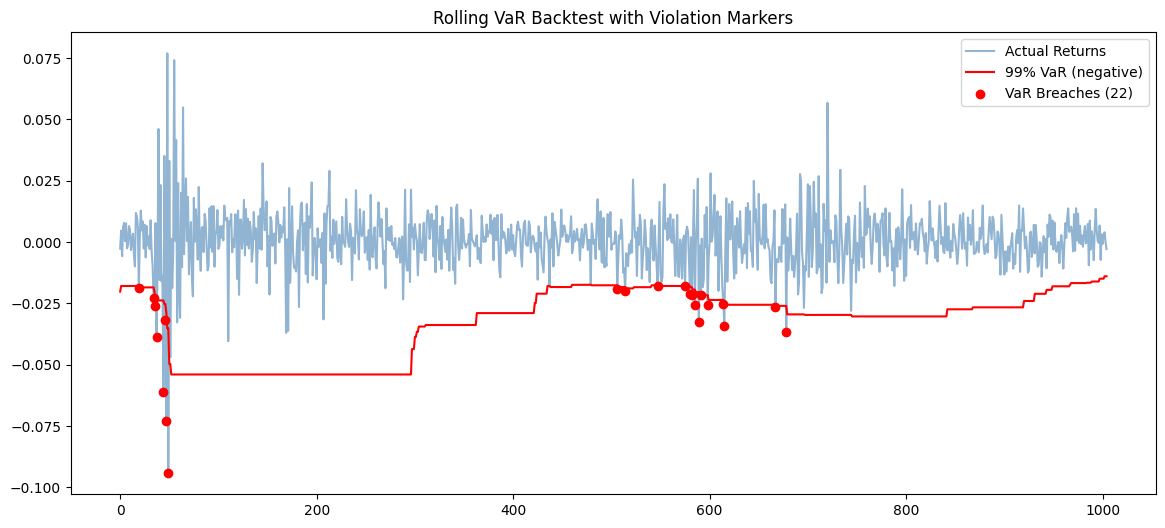

In [18]:
from src.backtesting import rolling_var_backtest, kupiec_test

port_ret = log_returns.dot(weights)
violations, var_series, actual = rolling_var_backtest(port_ret)
result = kupiec_test(violations, confidence_level=0.99)

print("\n--- Kupiec VaR Backtest Results ---")
for k, v in result.items():
    print(f"{k}: {v}")

# Visualize

plt.figure(figsize=(14, 6))
plt.plot(actual, color='steelblue', alpha=0.6, label='Actual Returns')
plt.plot(-var_series, color='red', linewidth=1.5, label='99% VaR (negative)')
breach_idx = np.where(violations == 1)[0]
plt.scatter(breach_idx, actual[breach_idx], color='red',
            zorder=5, label=f'VaR Breaches ({violations.sum()})')
plt.title('Rolling VaR Backtest with Violation Markers')
plt.legend()
plt.savefig('../outputs/backtest.png', dpi=150)
plt.show()